Download Data

In [10]:
!pip install gdown -q

# Google Drive folder ID (from the shared link)
FOLDER_ID = "1rsWlKjhOOJYaZ40K_lm3ZBffBBebIrt9"

# Download the entire folder
!gdown --folder {FOLDER_ID}

!ls -lh csv_data/

Retrieving folder contents
Processing file 1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW events_daily.csv
Processing file 16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn repo_languages.csv
Processing file 1FgxCE7XuFV8_2Y2QYVitjG7xLHm6HFoV repo_metadata.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW
From (redirected): https://drive.google.com/uc?id=1DPY7PL3wK14c7xHKLiBjjxBauZP0xMfW&confirm=t&uuid=e7301443-b709-4a29-82d1-d27a4b680aa0
To: /content/csv_data/events_daily.csv
100% 2.85G/2.85G [00:52<00:00, 54.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn
From (redirected): https://drive.google.com/uc?id=16Tvtn__M-OtHp5zzi8Y0r2l4S-9X2zQn&confirm=t&uuid=462b2d19-5dab-4192-9480-98acb3be9e9e
To: /content/csv_data/repo_languages.csv
100% 111M/111M [00:00<00:00, 131MB/s]
Downloading...
From (original): https:/

Collect Data

In [11]:
import os
import subprocess
from pathlib import Path

DATA_DIR = Path("/content/csv_data")

# Check that the folder exists
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Folder {DATA_DIR} not found. First download the data using gdown.")
print("=" * 60)
print("STEP 1: COLLECT INITIAL DATA")
print("=" * 60)

# 1. Collect all CSV files in the folder
csv_files = list(DATA_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")
for f in csv_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    size_gb = size_mb / 1024
    print(f"   - {f.name} ({size_mb:.2f} MB / {size_gb:.2f} GB)")

# 2. Folder structure analysis (only one folder here)
print("\nFOLDER STRUCTURE AND RELATIONSHIPS BETWEEN TABLES")
print(f"All files are located in: {DATA_DIR.resolve()}")
print("Structure:")
for f in csv_files:
    print(f"   - {f.name}")

# 3. Get row count information (fast using wc -l)
print("\nRow counts :")
for f in csv_files:
    try:
        line_count = int(subprocess.check_output(f"wc -l {f}", shell=True).split()[0])
        print(f"   - {f.name}: {line_count:,} rows (including header)")
    except Exception as e:
        print(f"   - {f.name}: failed to count rows — {e}")

# 4. Determine column names (only headers, without loading full data)
print("\nCOLUMN NAMES (from first row):")
for f in csv_files:
    try:
        import pandas as pd
        cols = pd.read_csv(f, nrows=0).columns.tolist()
        print(f"   - {f.name}: {len(cols)} columns: {cols[:5]}{' ...' if len(cols)>5 else ''}")
    except Exception as e:
        print(f"   - {f.name}: failed to read headers — {e}")


STEP 1: COLLECT INITIAL DATA
CSV files found: 3
   - events_daily.csv (2718.78 MB / 2.66 GB)
   - repo_metadata.csv (647.65 MB / 0.63 GB)
   - repo_languages.csv (105.79 MB / 0.10 GB)

FOLDER STRUCTURE AND RELATIONSHIPS BETWEEN TABLES
All files are located in: /content/csv_data
Structure:
   - events_daily.csv
   - repo_metadata.csv
   - repo_languages.csv

Row counts :
   - events_daily.csv: 44,706,264 rows (including header)
   - repo_metadata.csv: 10,389,096 rows (including header)
   - repo_languages.csv: 2,957,294 rows (including header)

COLUMN NAMES (from first row):
   - events_daily.csv: 6 columns: ['event_type', 'repo_id', 'repo_name', 'event_date', 'event_count'] ...
   - repo_metadata.csv: 3 columns: ['repo_id', 'repo_name', 'repo_first_seen']
   - repo_languages.csv: 3 columns: ['repo_name', 'language', 'language_bytes']


Describe Data

In [12]:
import time
import pandas as pd
import os
from pathlib import Path
from collections import defaultdict

DATA_DIR = Path("/content/csv_data")
csv_files = list(DATA_DIR.glob("*.csv"))

print("DATA DESCRIPTION – ALL TABLES WITH RELATIONSHIP ANALYSIS")
print("=" * 70)

# Fast row counting function
def count_rows_fast(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        next(f)  # skip header
        row_count = sum(1 for _ in f)
    return row_count + 1  # +1 for header

# Metadata storage for all tables
tables_meta = {}

for i, file_path in enumerate(csv_files, 1):
    file_name = os.path.basename(file_path)
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"\n[{i}/{len(csv_files)}] Processing: {file_name} ({size_mb:.2f} MB)")

    try:
        columns = pd.read_csv(file_path, nrows=0).columns.tolist()
        sample = pd.read_csv(file_path, nrows=1000)

        num_rows = count_rows_fast(file_path)
        print(f"   Rows: {num_rows:,}")
        print(f"   Columns: {len(columns)}")
        print(f"   Columns: {columns}")

        # Unit of analysis (determined by file name and structure)
        unit_of_analysis = "not determined"
        if file_name == "repo_languages.csv":
            unit_of_analysis = "Each row = (repository, programming language)"
        elif file_name == "events_daily.csv":
            unit_of_analysis = "Each row = (repository, day, event type)"
        elif file_name == "repo_metadata.csv":
            unit_of_analysis = "Each row = unique repository"

        print(f"   Unit of analysis: {unit_of_analysis}")

        # Save metadata for relationship analysis
        tables_meta[file_name] = {
            'columns': set(columns),
            'rows': num_rows,
            'sample': sample
        }

        # First 5 rows (for illustration)
        print("\n   First 5 rows:")
        with pd.option_context('display.max_columns', None, 'display.width', 120):
            print(sample.head(5).to_string(index=False))
        print("-" * 70)

    except Exception as e:
        print(f"   Error: {e}")

print("\n" + "=" * 70)
print("RELATIONSHIPS BETWEEN TABLES")
print("=" * 70)

# Find common columns between all pairs of tables
table_names = list(tables_meta.keys())
for i in range(len(table_names)):
    for j in range(i+1, len(table_names)):
        t1 = table_names[i]
        t2 = table_names[j]
        common_cols = tables_meta[t1]['columns'] & tables_meta[t2]['columns']
        if common_cols:
            print(f"\n {t1}  <-->  {t2}")
            print(f"   Common columns: {common_cols}")
            # Recommendation on join key
            if 'repo_id' in common_cols:
                print("   Recommended join key: `repo_id` (numeric, unique)")
                print("   Relationship type: one-to-many (metadata → events_daily)")
            elif 'repo_name' in common_cols:
                print("   Potential key: `repo_name` – but duplicates possible (different owners)")
                print("   Recommendation: add `repo_id` to the table that lacks it")
        else:
            print(f"\n {t1}  <-->  {t2} : no common columns found")

DATA DESCRIPTION – ALL TABLES WITH RELATIONSHIP ANALYSIS

[1/3] Processing: events_daily.csv (2718.78 MB)
   Rows: 44,706,265
   Columns: 6
   Columns: ['event_type', 'repo_id', 'repo_name', 'event_date', 'event_count', 'unique_actors']
   Unit of analysis: Each row = (repository, day, event type)

   First 5 rows:
 event_type   repo_id                                                           repo_name event_date  event_count  unique_actors
CreateEvent 159994330                                                TheHurricanes/abcsql 2023-01-01            1              1
CreateEvent 528105930                                      EddyKubwimana/Class_definition 2023-01-01            1              1
CreateEvent 584045020 codestar-github-bot-us-west-1/user-public-seeded-csc-repo-us-west-1 2023-01-01            2              2
CreateEvent 361493000                                           superflyxxi/phone-compare 2023-01-01            3              1
CreateEvent 189549010                 

Explore Data

Data loaded.
repo_languages: 2,957,293 rows, 3 columns
repo_metadata: 10,389,095 rows, 3 columns
events_daily will be processed in chunks.

ANALYSIS OF repo_languages.csv – language distribution and code volume

--- Statistics for language_bytes ---
count      2957293.00
mean       3071185.62
std       40442945.94
min              0.00
25%           8389.00
50%          31999.00
75%         164507.00
90%        1126712.00
95%        3747276.80
99%       27381310.76
max     5395746994.00
Name: language_bytes, dtype: float64
Percentage of zero values: 0.03%
Skewness: 43.71 (highly right‑skewed distribution)

Top‑10 languages by total code volume (bytes):
language
C                   5842140266149
JavaScript          1100866331897
PHP                  476185351977
C++                  371540951924
Java                 275381410067
HTML                 275023035003
Python               148325719683
C#                   119219561832
Go                    66255194314
Jupyter Notebook      63

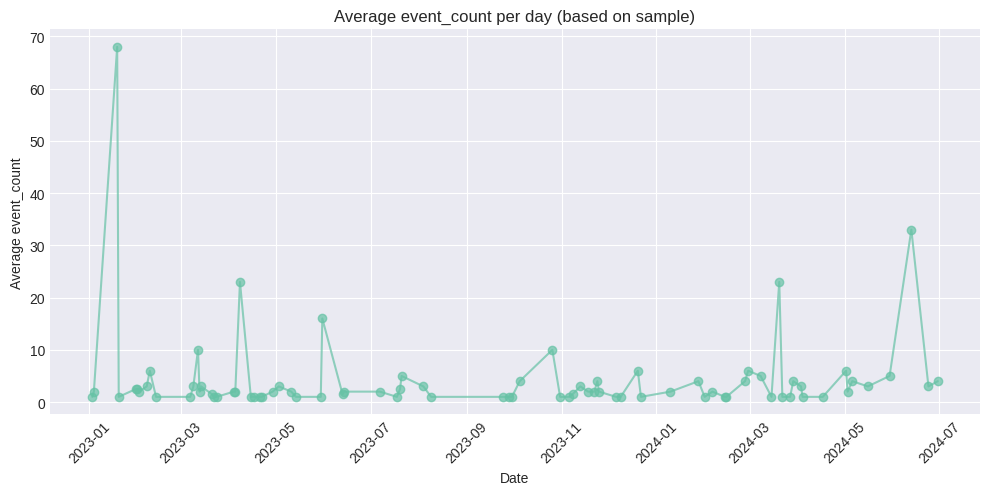

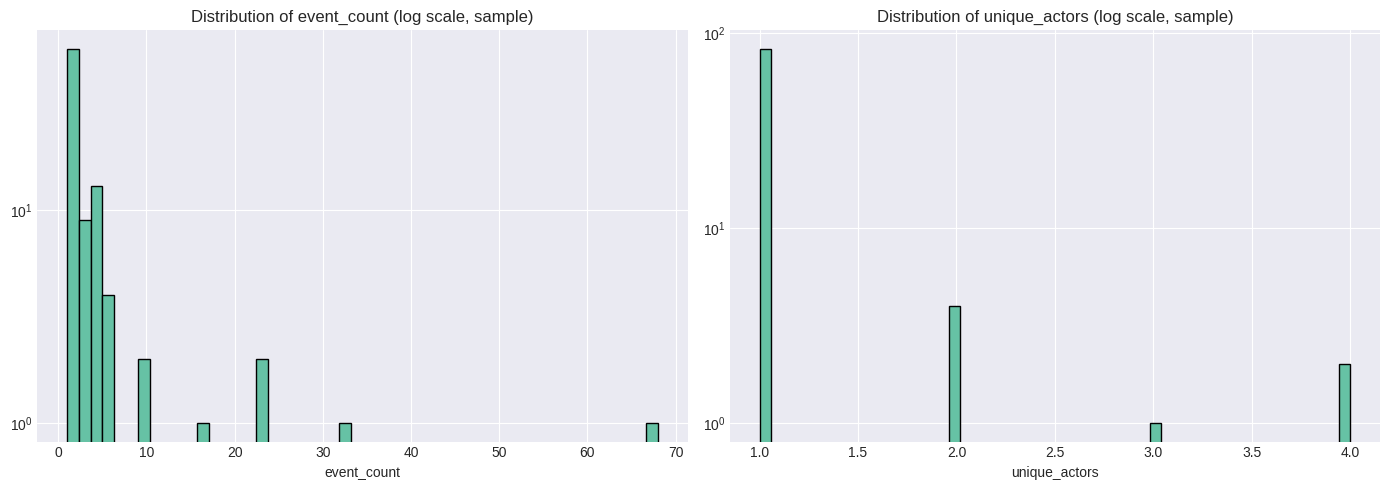


ANALYSIS OF repo_metadata.csv – first seen date, repo_id uniqueness

Earliest date: 2023-01-01 00:00:02+00:00
Latest date: 2024-06-30 23:59:59+00:00
Missing dates: 0


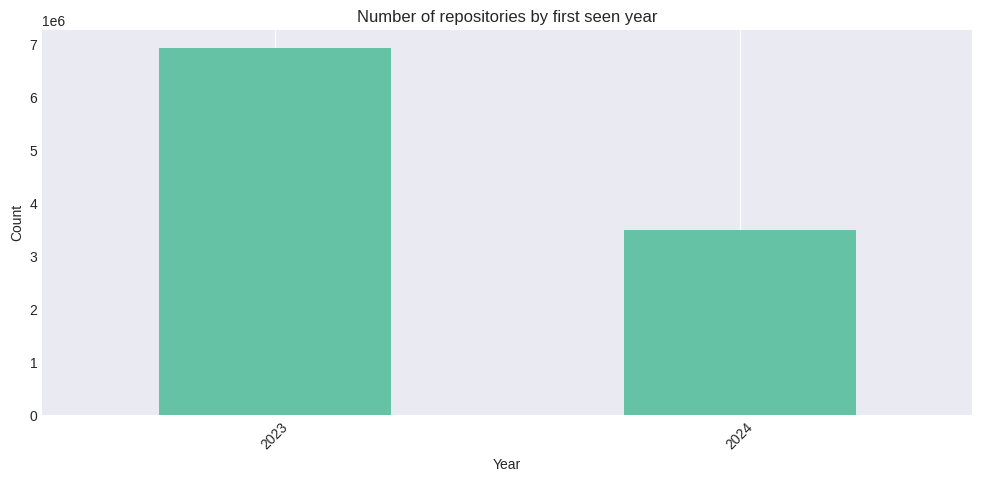


repo_id is unique: False
Number of duplicate repo_id: 109047

SUBPOPULATION ANALYSIS: repositories younger than 180 days
Max date in data: 2024-06-30
Repositories created in the last 180 days: 3,444,228 (33.2%)
Of these, have language info: 1,034

Top‑10 languages among young repositories (by number of repos):
language
JavaScript    179
Python        147
PHP            93
Java           83
HTML           65
C              58
Ruby           55
C#             55
C++            53
Go             35
Name: repo_id, dtype: int64


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_DIR = "/content/csv_data"

# Load small tables completely
repo_languages = pd.read_csv(f"{DATA_DIR}/repo_languages.csv")
repo_metadata = pd.read_csv(f"{DATA_DIR}/repo_metadata.csv")

# For events_daily we will use chunks (500,000 rows each)
chunk_size = 500000

print("Data loaded.")
print(f"repo_languages: {repo_languages.shape[0]:,} rows, {repo_languages.shape[1]} columns")
print(f"repo_metadata: {repo_metadata.shape[0]:,} rows, {repo_metadata.shape[1]} columns")
print("events_daily will be processed in chunks.\n")

print("="*70)
print("ANALYSIS OF repo_languages.csv – language distribution and code volume")
print("="*70)

# 2.1 Descriptive statistics for language_bytes
print("\n--- Statistics for language_bytes ---")
stats_bytes = repo_languages['language_bytes'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
print(stats_bytes)
zero_pct = (repo_languages['language_bytes'] == 0).mean() * 100
print(f"Percentage of zero values: {zero_pct:.2f}%")
skew_bytes = repo_languages['language_bytes'].skew()
print(f"Skewness: {skew_bytes:.2f} (highly right‑skewed distribution)")

# 2.2 Top‑10 languages by total code volume
lang_bytes_sum = repo_languages.groupby('language')['language_bytes'].sum().sort_values(ascending=False).head(10)
print("\nTop‑10 languages by total code volume (bytes):")
print(lang_bytes_sum)

# 2.3 Top‑10 languages by number of repositories
lang_repo_count = repo_languages.groupby('language')['repo_name'].nunique().sort_values(ascending=False).head(10)
print("\nTop‑10 languages by number of repositories:")
print(lang_repo_count)


print("\n" + "="*70)
print("ANALYSIS OF events_daily.csv – event types, distributions, relationships")
print("="*70)

# Aggregators
total_rows = 0
event_type_counts = {}
date_min, date_max = None, None
event_count_sum = 0
unique_actors_sum = 0
sample_events = []

chunk_iter = pd.read_csv(f"{DATA_DIR}/events_daily.csv", chunksize=chunk_size)

for i, chunk in enumerate(chunk_iter):
    total_rows += len(chunk)
    for et, cnt in chunk['event_type'].value_counts().items():
        event_type_counts[et] = event_type_counts.get(et, 0) + cnt

    event_dates = pd.to_datetime(chunk['event_date'])
    c_min = event_dates.min()
    c_max = event_dates.max()
    if date_min is None or c_min < date_min:
        date_min = c_min
    if date_max is None or c_max > date_max:
        date_max = c_max

    event_count_sum += chunk['event_count'].sum()
    unique_actors_sum += chunk['unique_actors'].sum()

    if len(sample_events) < 10000:
        sample_events.append(chunk.sample(min(1000, len(chunk))))
    if (i+1) % 5 == 0:
        print(f"Processed {i+1} chunks, total rows: {total_rows:,}")

sample_events_df = pd.concat(sample_events).sample(min(10000, len(sample_events)))
print(f"\nTotal rows in events_daily: {total_rows:,}")
print(f"Date range: from {date_min} to {date_max}")
print(f"Sum of event_count: {event_count_sum:,}")
print(f"Sum of unique_actors: {unique_actors_sum:,}")

# 3.1 Top‑10 event types
top_events = pd.Series(event_type_counts).sort_values(ascending=False).head(10)
print("\nTop‑10 event types (record count):")
print(top_events)
push_pct = top_events.get('PushEvent', 0) / total_rows * 100
print(f"PushEvent share: {push_pct:.1f}%")

# 3.2 Daily average event_count (based on sample)
sample_events_df['event_date'] = pd.to_datetime(sample_events_df['event_date'])
daily_avg = sample_events_df.groupby('event_date')['event_count'].mean()
plt.figure(figsize=(12,5))
plt.plot(daily_avg.index, daily_avg.values, marker='o', linestyle='-', alpha=0.7)
plt.title('Average event_count per day (based on sample)')
plt.xlabel('Date')
plt.ylabel('Average event_count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 3.3 Distribution of event_count and unique_actors (sample)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(sample_events_df['event_count'], bins=50, log=True, edgecolor='black')
axes[0].set_title('Distribution of event_count (log scale, sample)')
axes[0].set_xlabel('event_count')
axes[1].hist(sample_events_df['unique_actors'], bins=50, log=True, edgecolor='black')
axes[1].set_title('Distribution of unique_actors (log scale, sample)')
axes[1].set_xlabel('unique_actors')
plt.tight_layout()
plt.show()


print("\n" + "="*70)
print("ANALYSIS OF repo_metadata.csv – first seen date, repo_id uniqueness")
print("="*70)

repo_metadata['repo_first_seen'] = pd.to_datetime(repo_metadata['repo_first_seen'], errors='coerce')
print(f"\nEarliest date: {repo_metadata['repo_first_seen'].min()}")
print(f"Latest date: {repo_metadata['repo_first_seen'].max()}")
print(f"Missing dates: {repo_metadata['repo_first_seen'].isnull().sum()}")

# Distribution by year
repo_metadata['year'] = repo_metadata['repo_first_seen'].dt.year
year_counts = repo_metadata['year'].value_counts().sort_index()
plt.figure(figsize=(12,5))
year_counts.plot(kind='bar')
plt.title('Number of repositories by first seen year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# Uniqueness of repo_id
print(f"\nrepo_id is unique: {repo_metadata['repo_id'].is_unique}")
print(f"Number of duplicate repo_id: {repo_metadata['repo_id'].duplicated().sum()}")


print("\n" + "="*70)
print("SUBPOPULATION ANALYSIS: repositories younger than 180 days")
print("="*70)

max_date = repo_metadata['repo_first_seen'].max()
cutoff_date = max_date - pd.Timedelta(days=180)
young_repos = repo_metadata[repo_metadata['repo_first_seen'] >= cutoff_date]
print(f"Max date in data: {max_date.date()}")
print(f"Repositories created in the last 180 days: {len(young_repos):,} ({len(young_repos)/len(repo_metadata)*100:.1f}%)")

# Merge with languages
merged_young = pd.merge(young_repos, repo_languages, on='repo_name', how='inner')
print(f"Of these, have language info: {len(merged_young):,}")
if not merged_young.empty:
    top_langs_young = merged_young.groupby('language')['repo_id'].nunique().sort_values(ascending=False).head(10)
    print("\nTop‑10 languages among young repositories (by number of repos):")
    print(top_langs_young)
else:
    print("No matching records when joining by repo_name – names may not match exactly.")

Verify Data Quality

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "/content/csv_data"

# Load small tables
repo_languages = pd.read_csv(f"{DATA_DIR}/repo_languages.csv")
repo_metadata = pd.read_csv(f"{DATA_DIR}/repo_metadata.csv")

# For events_daily we will use chunks (500,000 rows each)
chunk_size = 500000

print("Data loaded.")
print(f"repo_languages: {repo_languages.shape}")
print(f"repo_metadata: {repo_metadata.shape}")
print("events_daily will be processed in chunks.\n")


def check_duplicates(df, table_name):
    """Check for duplicate rows (handling list columns)"""
    if not isinstance(df, pd.DataFrame):
        print(f"   ! {table_name}: not a DataFrame – skipping")
        return
    temp = df.copy()
    for col in temp.columns:
        if temp[col].apply(lambda x: isinstance(x, list)).any():
            temp[col] = temp[col].apply(lambda x: str(x) if isinstance(x, list) else x)
    dups = temp.duplicated(keep=False)
    count = dups.sum()
    if count > 0:
        print(f"   ! {table_name}: found {count} duplicate rows.")
        print(df[dups].head(3))
    else:
        print(f"   + {table_name}: no duplicate rows.")

def check_missing(df, table_name):
    """Check for missing values"""
    if not isinstance(df, pd.DataFrame):
        print(f"   ! {table_name}: not a DataFrame – skipping")
        return
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_cols = missing[missing > 0]
    if not missing_cols.empty:
        print(f"   ! {table_name}: missing values found.")
        for col in missing_cols.index:
            print(f"      - {col}: {missing[col]} missing ({missing_pct[col]:.2f}%)")
    else:
        print(f"   + {table_name}: no missing values.")

def check_outliers_numeric(df, table_name, cols, threshold=3):
    """Outliers using Z-score (for numeric columns)"""
    if not isinstance(df, pd.DataFrame):
        print(f"   ! {table_name}: not a DataFrame – skipping")
        return
    print(f"   Outliers in {table_name}:")
    for col in cols:
        if col not in df.columns:
            continue
        data = df[col].dropna()
        if len(data) == 0:
            continue
        z = np.abs(stats.zscore(data))
        outliers = data[(z > threshold)]
        pct = len(outliers) / len(data) * 100
        if len(outliers) > 0:
            print(f"      - {col}: {len(outliers)} outliers ({pct:.2f}%) |z|>{threshold}")
        else:
            print(f"      - {col}: no significant outliers (|z|≤{threshold})")

def check_logical_errors(df, table_name):
    """Logical errors (negative values, invalid ranges, etc.)"""
    if not isinstance(df, pd.DataFrame):
        print(f"   ! {table_name}: not a DataFrame – skipping")
        return
    errors = []
    if 'language_bytes' in df.columns:
        neg = (df['language_bytes'] < 0).sum()
        if neg > 0:
            errors.append(f"      - Negative language_bytes: {neg}")
    if 'event_count' in df.columns:
        neg = (df['event_count'] < 0).sum()
        if neg > 0:
            errors.append(f"      - Negative event_count: {neg}")
    if 'unique_actors' in df.columns:
        neg = (df['unique_actors'] < 0).sum()
        if neg > 0:
            errors.append(f"      - Negative unique_actors: {neg}")
    if 'repo_id' in df.columns:
        invalid = (df['repo_id'] <= 0).sum()
        if invalid > 0:
            errors.append(f"      - Invalid repo_id (≤0): {invalid}")
    if 'repo_first_seen' in df.columns:
        dates = df['repo_first_seen']
        if dates.dt.tz is not None:
            dates = dates.dt.tz_localize(None)
        min_date = pd.to_datetime('2000-01-01')
        max_date = pd.Timestamp.now().tz_localize(None)
        invalid_dates = ((dates < min_date) | (dates > max_date)).sum()
        if invalid_dates > 0:
            errors.append(f"      - repo_first_seen dates outside reasonable range (2000-present): {invalid_dates}")
    if errors:
        print(f"   ! {table_name}: logical errors found.")
        for e in errors:
            print(e)
    else:
        print(f"   + {table_name}: no logical errors.")

def check_data_types(df, table_name):
    """Check data types and detect inconsistencies"""
    if not isinstance(df, pd.DataFrame):
        print(f"   ! {table_name}: not a DataFrame – skipping")
        return
    print(f"   Data types in {table_name}:")
    for col in df.columns:
        dtype = df[col].dtype
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None
        if dtype == 'object':
            if sample is not None:
                if isinstance(sample, list):
                    print(f"      - {col}: object (list)")
                else:
                    # Try to determine if string is a date
                    try:
                        pd.to_datetime(sample)
                        print(f"      - {col}: object (likely date)")
                    except:
                        print(f"      - {col}: object (string)")
            else:
                print(f"      - {col}: object (all null)")
        else:
            print(f"      - {col}: {dtype}")

def data_quality_report(df, table_name, numeric_cols=None):
    """Full quality report for one table"""
    print(f"\n--- Quality check for table: {table_name} ---")
    check_duplicates(df, table_name)
    check_missing(df, table_name)
    if numeric_cols and isinstance(df, pd.DataFrame):
        check_outliers_numeric(df, table_name, numeric_cols)
    check_logical_errors(df, table_name)
    check_data_types(df, table_name)


print("\n" + "="*70)
print("DATA QUALITY CHECK: repo_languages.csv")
print("="*70)

numeric_cols_lang = ['language_bytes']
data_quality_report(repo_languages, 'repo_languages', numeric_cols=numeric_cols_lang)

print("\n" + "="*70)
print("DATA QUALITY CHECK: repo_metadata.csv")
print("="*70)

# Convert date for checks
repo_metadata['repo_first_seen'] = pd.to_datetime(repo_metadata['repo_first_seen'], errors='coerce')
numeric_cols_meta = ['repo_id']
data_quality_report(repo_metadata, 'repo_metadata', numeric_cols=numeric_cols_meta)

print("\n" + "="*70)
print("DATA QUALITY CHECK: events_daily.csv (chunked processing)")
print("="*70)

# Initialize counters for aggregated statistics over all chunks
total_rows = 0
total_missing_event_type = 0
total_missing_repo_id = 0
total_missing_repo_name = 0
total_missing_event_date = 0
total_missing_event_count = 0
total_missing_unique_actors = 0
total_neg_event_count = 0
total_neg_unique_actors = 0
total_neg_repo_id = 0

chunk_iter = pd.read_csv(f"{DATA_DIR}/events_daily.csv", chunksize=chunk_size)

for i, chunk in enumerate(chunk_iter):
    total_rows += len(chunk)
    total_missing_event_type += chunk['event_type'].isnull().sum()
    total_missing_repo_id += chunk['repo_id'].isnull().sum()
    total_missing_repo_name += chunk['repo_name'].isnull().sum()
    total_missing_event_date += chunk['event_date'].isnull().sum()
    total_missing_event_count += chunk['event_count'].isnull().sum()
    total_missing_unique_actors += chunk['unique_actors'].isnull().sum()
    total_neg_event_count += (chunk['event_count'] < 0).sum()
    total_neg_unique_actors += (chunk['unique_actors'] < 0).sum()
    total_neg_repo_id += (chunk['repo_id'] <= 0).sum()
    if (i+1) % 5 == 0:
        print(f"Processed {i+1} chunks, total rows: {total_rows:,}")

print(f"\nTotal rows in events_daily: {total_rows:,}")

# Print missing values results
print("\n--- Missing values in events_daily ---")
if total_missing_event_type > 0:
    print(f"   ! event_type: {total_missing_event_type} missing ({total_missing_event_type/total_rows*100:.4f}%)")
else:
    print("   + event_type: no missing values")
if total_missing_repo_id > 0:
    print(f"   ! repo_id: {total_missing_repo_id} missing ({total_missing_repo_id/total_rows*100:.4f}%)")
else:
    print("   + repo_id: no missing values")
if total_missing_repo_name > 0:
    print(f"   ! repo_name: {total_missing_repo_name} missing ({total_missing_repo_name/total_rows*100:.4f}%)")
else:
    print("   + repo_name: no missing values")
if total_missing_event_date > 0:
    print(f"   ! event_date: {total_missing_event_date} missing ({total_missing_event_date/total_rows*100:.4f}%)")
else:
    print("   + event_date: no missing values")
if total_missing_event_count > 0:
    print(f"   ! event_count: {total_missing_event_count} missing ({total_missing_event_count/total_rows*100:.4f}%)")
else:
    print("   + event_count: no missing values")
if total_missing_unique_actors > 0:
    print(f"   ! unique_actors: {total_missing_unique_actors} missing ({total_missing_unique_actors/total_rows*100:.4f}%)")
else:
    print("   + unique_actors: no missing values")

# Logical errors
print("\n--- Logical errors in events_daily ---")
if total_neg_event_count > 0:
    print(f"   ! Negative event_count: {total_neg_event_count}")
else:
    print("   + No negative event_count")
if total_neg_unique_actors > 0:
    print(f"   ! Negative unique_actors: {total_neg_unique_actors}")
else:
    print("   + No negative unique_actors")
if total_neg_repo_id > 0:
    print(f"   ! Invalid repo_id (≤0): {total_neg_repo_id}")
else:
    print("   + No invalid repo_id")

# For outlier and type checks, use a sample
sample_events = pd.read_csv(f"{DATA_DIR}/events_daily.csv", nrows=10000)
numeric_cols_events = ['repo_id', 'event_count', 'unique_actors']
check_outliers_numeric(sample_events, 'events_daily (sample)', numeric_cols_events)
check_data_types(sample_events, 'events_daily (sample)')

print("\n" + "="*70)
print("REFERENTIAL INTEGRITY CHECKS")
print("="*70)

# 5.1. Primary key uniqueness
print("\n--- Primary key uniqueness ---")
if repo_metadata['repo_id'].is_unique:
    print("   + repo_metadata: repo_id is unique.")
else:
    dup_count = repo_metadata['repo_id'].duplicated().sum()
    print(f"   ! repo_metadata: found {dup_count} duplicate repo_id.")
lang_pairs = repo_languages[['repo_name', 'language']].duplicated().sum()
if lang_pairs == 0:
    print("   + repo_languages: (repo_name, language) pairs are unique.")
else:
    print(f"   ! repo_languages: {lang_pairs} duplicate (repo_name, language) pairs.")

# 5.2. Referential integrity: do all repo_id from events_daily exist in repo_metadata?
print("\n--- Referential integrity (events_daily → repo_metadata) ---")
unique_repo_ids_in_events = set()
chunk_iter2 = pd.read_csv(f"{DATA_DIR}/events_daily.csv", chunksize=chunk_size, usecols=['repo_id'])
for chunk in chunk_iter2:
    unique_repo_ids_in_events.update(chunk['repo_id'].dropna().unique())
print(f"Unique repo_id in events_daily: {len(unique_repo_ids_in_events)}")
repo_ids_in_metadata = set(repo_metadata['repo_id'].dropna().unique())
missing_in_metadata = unique_repo_ids_in_events - repo_ids_in_metadata
if missing_in_metadata:
    print(f"   ! Found {len(missing_in_metadata)} repo_id from events_daily missing in repo_metadata.")
    print(f"     Examples: {list(missing_in_metadata)[:5]}")
else:
    print("   + All repo_id from events_daily are present in repo_metadata.")

# 5.3. Referential integrity: do all repo_name from repo_languages exist in repo_metadata?
print("\n--- Referential integrity (repo_languages → repo_metadata) ---")
repo_names_lang = set(repo_languages['repo_name'].dropna().unique())
repo_names_meta = set(repo_metadata['repo_name'].dropna().unique())
missing_names = repo_names_lang - repo_names_meta
if missing_names:
    print(f"   ! Found {len(missing_names)} repo_name from repo_languages missing in repo_metadata.")
    print(f"     Examples: {list(missing_names)[:5]}")
else:
    print("   + All repo_name from repo_languages are present in repo_metadata.")

Data loaded.
repo_languages: (2957293, 3)
repo_metadata: (10389095, 3)
events_daily will be processed in chunks.


DATA QUALITY CHECK: repo_languages.csv

--- Quality check for table: repo_languages ---
   + repo_languages: no duplicate rows.
   + repo_languages: no missing values.
   Outliers in repo_languages:
      - language_bytes: 14641 outliers (0.50%) |z|>3
   + repo_languages: no logical errors.
   Data types in repo_languages:
      - repo_name: object (string)
      - language: object (string)
      - language_bytes: int64

DATA QUALITY CHECK: repo_metadata.csv

--- Quality check for table: repo_metadata ---
   + repo_metadata: no duplicate rows.
   + repo_metadata: no missing values.
   Outliers in repo_metadata:
      - repo_id: 350965 outliers (3.38%) |z|>3
   + repo_metadata: no logical errors.
   Data types in repo_metadata:
      - repo_id: int64
      - repo_name: object (string)
      - repo_first_seen: datetime64[ns, UTC]

DATA QUALITY CHECK: events_daily.csv (chunke